# Libraries and functions

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
from torch.utils.data import Dataset

device = torch.device("cuda:1")

data_PATH = "./"

In [9]:
class RandomDatasetPowerLaw(Dataset):
    """Binary random–feature dataset with power‑law coefficients

    Parameters
    ----------
    P : int
        Number of patterns
    N : int
        Size of the vectors
    D : int
        Number of random features
    d : int
        Dimensionality of each site 
    eta : float
        Exponent controlling biased feature selection (if pick_biased is not None)
    sigma : float, default 1.
        Std‑dev of the Gaussian entries used for both xi and teacher weights
    L : int or None, default None
        If not None, only the first L of the D features are kept 
    seed : int or None
        Random seed 
    on_sphere : bool, default True
        If True, each vector is L2‑normalised
    coefficients : {'binary', 'gaussian'}
        Distribution of coefficients c multiplying the random field
    variances : {'power_law', 'exponential', None}
        Variance modulation of c
    exponent : float or None
        Power‑law exponent of variances, if variances == 'power_law'
    shift : int, default 0
        Shift applied to the power‑law index (k + shift)^‑exponent
    pick_biased : bool or None
        If not None, randomly zero‑out D‑L coefficients with given bias probability 
    """

    def __init__(self, P, N, D, d, eta=None, sigma=1., L=None, seed=None, *, spin_type="vector",
                 coefficients="binary", variances=None, exponent=None, shift=0,
                 pick_biased=False):

        super().__init__()
        self.P, self.N, self.D, self.L = P, N, D,  L or D
        if self.L > self.D:
            raise ValueError("L must be ≤ D")
        self.d, self.sigma, self.spin_type = d, sigma, spin_type
        self.coefficients, self.variances = coefficients, variances
        self.exponent, self.shift, self.pick_biased = exponent, shift, pick_biased
        self.eta = eta 

        if seed is not None:
            torch.manual_seed(seed)

        self.xi = torch.randn(P, N, d, dtype=torch.float32) * sigma

        if self.D > 0:
            self._apply_random_field(seed=seed + 111 if seed is not None else None)

        if spin_type=="vector":
            self.xi = self._l2_normalise(self.xi)

        self.sample_weights = torch.ones(P, dtype=torch.float32)

    def _apply_random_field(self, *, seed=None):
        """Construct features f_k and coefficients c
        """
        if seed is not None:
            torch.manual_seed(seed)

        f = torch.randn(self.D, self.N, self.d, dtype=torch.float32) * self.sigma
        if self.spin_type=="vector":
            f = self._l2_normalise(f)
        self.f = f  

        if self.coefficients == "binary":
            c = torch.randint(0, 2, (self.P, self.D), dtype=torch.float32) * 2 - 1
        elif self.coefficients == "gaussian":
            c = torch.randn(self.P, self.D, dtype=torch.float32)
        else:
            raise ValueError("coefficients must be 'binary' or 'gaussian'")

        c = c / math.sqrt(self.D)  

        if self.variances == "power_law":
            variances = torch.arange(1 + self.shift, self.D + 1 + self.shift, dtype=torch.float32).pow(-self.exponent)
            c *= variances 
        elif self.variances == "exponential":
            lam = 10.0 / float(self.D)
            variances = torch.exp(-torch.arange(1, self.D + 1, dtype=torch.float32) * lam)
            c *= variances

        if self.pick_biased is True and self.L < self.D:
            idx = torch.arange(self.D)
            bias = (1+idx).float().pow(-self.eta)
            bias /= bias.sum()
            keep_idx = torch.stack([torch.multinomial(bias, self.L, replacement=False) for _ in range(self.P)])
            mask = torch.zeros_like(c).bool()
            mask.scatter_(1, keep_idx, True)
            c = c.masked_fill(~mask, 0.0)

        self.xi = torch.einsum('pk,kid->pid', c, f)
        self.xi = self._l2_normalise(self.xi) if (self.spin_type=="vector") else self.xi
        self.c = c

    def _make_teacher_labels(self, teacher_seed=None):
        """Generate C random teacher weight vectors and assign labels by argmax."""
        if teacher_seed is not None:
            torch.manual_seed(teacher_seed)

        self.teacher_w = torch.randn(self.C, self.N, self.d, dtype=torch.float32) * self.sigma
        if self.spin_type=="vector":
            self.teacher_w = self._l2_normalise(self.teacher_w)

        xi_flat = self.xi.view(self.P, -1)
        w_flat = self.teacher_w.view(self.C, -1).t() 
        logits = xi_flat @ w_flat  
        self.labels = torch.argmax(logits, dim=1)

    def get_generalization(self, P_hat, L=None):
        """Return new patterns (without labels) sampled with independent coefficients."""
        L = L or self.L
        if L > self.D:
            raise ValueError("L must be ≤ D")
        if self.coefficients == "binary":
            c = torch.randint(0, 2, (P_hat, self.D), dtype=torch.float32) * 2 - 1
        elif self.coefficients == "gaussian":
            c = torch.randn(P_hat, self.D, dtype=torch.float32)
        else:
            raise ValueError("coefficients must be 'binary' or 'gaussian'")

        c = c / math.sqrt(self.D)  

        if self.variances == "power_law":
            variances = torch.arange(1 + self.shift, self.D + 1 + self.shift, dtype=torch.float32).pow(-self.exponent)
            c *= variances 
        elif self.variances == "exponential":
            lam = 10.0 / float(self.D)
            variances = torch.exp(-torch.arange(1, self.D + 1, dtype=torch.float32) * lam)
            c *= variances

        if self.pick_biased is not None and self.L < self.D:
            idx = torch.arange(self.D)
            bias = (1+idx).float().pow(-self.eta)
            bias /= bias.sum()
            keep_idx = torch.stack([torch.multinomial(bias, self.L, replacement=False) for _ in range(P_hat)])
            mask = torch.zeros_like(c).bool()
            mask.scatter_(1, keep_idx, True)
            c = c.masked_fill(~mask, 0.0)

        self.xi_new = torch.einsum('pk,kid->pid', c, self.f)
        self.xi_new = self._l2_normalise(self.xi_new) if (self.spin_type=="vector") else self.xi_new
        xi_new = torch.einsum('pk,kid->pid', c, self.f)
        xi_new = self._l2_normalise(xi_new) if (self.spin_type=="vector") else xi_new
        return xi_new
    
    def get_generalization_selected_features(self, P_hat, feature_range, L=None):
        if self.coefficients == "binary":
            c = torch.randint(0, 2, (P_hat, self.D)).float() * 2 - 1
        elif self.coefficients == "gaussian":
            c = torch.randn(P_hat, self.D)
        else:
            raise ValueError("coefficients must be 'binary' or 'gaussian'")

        c = c / math.sqrt(self.D)

        c = c[:, feature_range]  # Select the columns corresponding to feature_range

        indices_to_zero = torch.rand(P_hat, len(feature_range))
        indices_to_zero = indices_to_zero.argsort(dim=1)[:, : len(feature_range) - self.L]
        c = c.scatter(1, indices_to_zero, 0)

        selected_f = self.f[feature_range, :, :]  # Select only the relevant features from self.f

        self.xi_new = torch.einsum('pk,knd->pnd', c, selected_f)

        # Fill zeros with Gaussian noise
        mask = self.xi_new == 0
        filler = torch.randn_like(self.xi_new) * self.sigma
        self.xi_new = torch.where(mask, filler, self.xi_new)

        if self.spin_type == "vector":
            self.xi_new = self._l2_normalise(self.xi_new)

        return self.xi_new

    def _l2_normalise(self, x: torch.Tensor, eps: float = 0.0) -> torch.Tensor:
        """Normalise along last dimension to unit L2 norm; for d==1 use sign, with 0 -> +1."""
        if self.d == 1:
            if eps == 0.0:
                return torch.where(x == 0, torch.ones_like(x), torch.sign(x))
            else:
                return torch.where(x.abs() <= eps, torch.ones_like(x), torch.sign(x))
        else:
            eps = 1e-8
            norm = torch.norm(x)+eps
            result = x / norm
        return result
        
    def __len__(self):
        return self.P

    def __getitem__(self, idx):
        return self.xi[idx]

    def get_num_visibles(self):
        return self.N * self.d

    def get_num_classes(self):
        return self.C if self.C is not None else 0

# L=O(1) combined features, with bias in probability with exponent $\eta$

In [26]:
d=1
spin_type = "vector"

eta=1.5
pick_biased = True
L=3

N=1000
alpha_P = 5.
alpha_D = 0.1
P=int(alpha_P*N)
D=int(alpha_D*N)
seed = 1

dataset = RandomDatasetPowerLaw(P, N, D, d, eta=eta, L=L, seed=seed, spin_type=spin_type, coefficients="binary", shift=0, pick_biased=pick_biased)
xi = dataset.xi.to(device)
f =  dataset.f.to(device)

print(xi.shape)
print(f.shape)

torch.Size([5000, 1000, 1])
torch.Size([100, 1000, 1])


(1e-05, np.float64(359.61884474265565))

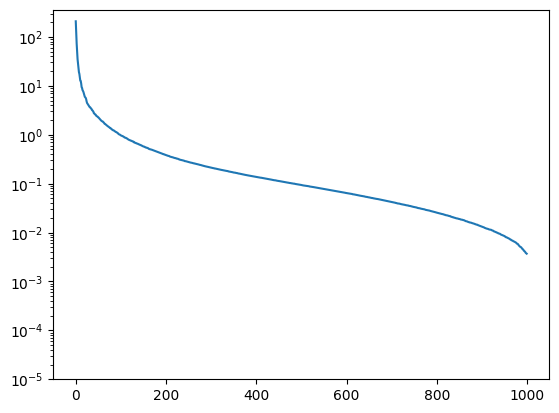

In [27]:
U_data, S_data, V_dataT = torch.linalg.svd(
    xi.squeeze() - xi.squeeze().mean(0)
)

plt.plot((S_data/torch.sqrt(torch.tensor(P))).cpu()**2)
plt.yscale("log")
plt.ylim(bottom=1e-5)

In [28]:
to_save = {
    "xi": xi.cpu(),
    "f": f.cpu()
}

np.savez("method_A", **to_save)


In [29]:
saved = np.load(data_PATH+"method_A.npz", allow_pickle=True)

xi = saved["xi"]
f = saved["f"]

print(xi.shape)
print(f.shape)

(5000, 1000, 1)
(100, 1000, 1)


# L=D combined features, with modulus of c decaying with exponent $\gamma$

In [30]:
# Nature of variables and loss
d=1
spin_type = "vector"

pick_biased = False
exponent = 1.1

# Step
n = 100

N=1000
alpha_P = 1.
alpha_D = 0.1
P=int(alpha_P*N)
D=int(alpha_D*N)
seed = 1

dataset = RandomDatasetPowerLaw(P, N, D, d, eta=eta, L=L, seed=seed, spin_type=spin_type, coefficients="binary", shift=0, pick_biased=pick_biased)
xi = dataset.xi.to(device)
f =  dataset.f.to(device)

print(xi.shape)
print(f.shape)

torch.Size([1000, 1000, 1])
torch.Size([100, 1000, 1])


(1e-05, np.float64(98.2361191234451))

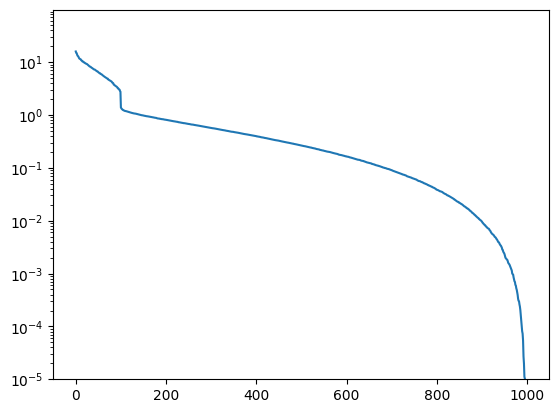

In [31]:
U_data, S_data, V_dataT = torch.linalg.svd(
    xi.squeeze() - xi.squeeze().mean(0)
)

plt.plot((S_data/torch.sqrt(torch.tensor(P))).cpu()**2)
plt.yscale("log")
plt.ylim(bottom=1e-5)

In [32]:
to_save = {
    "xi": xi.cpu(),
    "f": f.cpu()
}

np.savez("method_B", **to_save)


In [34]:
saved = np.load(data_PATH+"method_B.npz", allow_pickle=True)

xi = saved["xi"]
f = saved["f"]

print(xi.shape)
print(f.shape)

(1000, 1000, 1)
(100, 1000, 1)
